In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
BASE = Path(r"C:\docfusion_data\findit2")
PROJECT_ROOT = Path(r"C:\docfusion_project")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.datasets.findit_loader import load_findit_split

BASE.exists(), PROJECT_ROOT.exists()

(True, True)

In [3]:
train_df = load_findit_split(BASE, "train")
val_df   = load_findit_split(BASE, "val")
test_df  = load_findit_split(BASE, "test")

print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

train: (577, 4)
val:   (193, 4)
test:  (218, 4)


## Key Findings

- The train, validation, and test splits are loaded successfully.
- Class balance appears reasonably stable across splits.
- OCR text length features such as number of lines, words, and characters may help anomaly detection.
- Some documents may have missing images or unusually short OCR text, which should be handled in the baseline.
- Token frequency differences suggest that simple text-derived features may already provide a useful baseline for forged-document classification.

## Implications for the next step

The anomaly baseline should start with:
- text length features
- missingness / emptiness indicators
- simple lexical indicators
- a lightweight classical model such as Logistic Regression or Random Forest

In [4]:
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

df = pd.concat([train_df, val_df, test_df], ignore_index=True)
df.head()

,id,image_path,lines,is_forged,split
0,X00016469622,C:\docfusion_data\findit2\train\X00016469622.png,"[TAN WOON YANN, YONGFATT ENTERPRISE, (JM051772...",1,train
1,X00016469623,C:\docfusion_data\findit2\train\X00016469623.png,"[TAN WOON YANN, MR D.I.Y. (M) SDN BHD, (CO. RF...",0,train
2,X00016469670,C:\docfusion_data\findit2\train\X00016469670.png,"[TAN CHAY YEE, *** COPY ***, OJC MARKETING SDN...",0,train
3,X00016469671,C:\docfusion_data\findit2\train\X00016469671.png,"[TAN CHAY YEE, OJC MARKETING SDN BHD, ROC NO: ...",0,train
4,X00016469672,C:\docfusion_data\findit2\train\X00016469672.png,"[TAN CHAY YEE, SOON HUAT MACHINERY ENTERPRISE,...",0,train


In [5]:
print("Total rows:", len(df))
print("Duplicate IDs:", df["id"].duplicated().sum())
print("Missing image_path:", df["image_path"].isna().sum())
print("Missing lines column:", df["lines"].isna().sum())

Total rows: 988
Duplicate IDs: 1
Missing image_path: 0
Missing lines column: 0


In [6]:
df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists())

missing_images = df.loc[~df["image_exists"], ["id", "split", "image_path"]]
print("Missing image files:", len(missing_images))
missing_images.head(10)

Missing image files: 1


,id,split,image_path
693,X51006619709,val,C:\docfusion_data\findit2\val\X51006619709.png


In [7]:
df["text"] = df["lines"].apply(lambda x: " ".join(x) if isinstance(x, list) else "")
df["n_lines"] = df["lines"].apply(lambda x: len(x) if isinstance(x, list) else 0)
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().apply(len)
df["avg_line_len"] = np.where(df["n_lines"] > 0, df["n_chars"] / df["n_lines"], 0)

df[["id", "split", "is_forged", "n_lines", "n_chars", "n_words", "avg_line_len"]].head()

,id,split,is_forged,n_lines,n_chars,n_words,avg_line_len
0,X00016469622,train,1,60,584,105,9.733333
1,X00016469623,train,0,61,797,144,13.065574
2,X00016469670,train,0,47,664,111,14.127660
3,X00016469671,train,0,41,576,94,14.048780
4,X00016469672,train,0,93,916,157,9.849462


In [8]:
split_summary = (
    df.groupby("split")
      .agg(
          n_docs=("id", "count"),
          forged_count=("is_forged", "sum"),
          forged_rate=("is_forged", "mean"),
          avg_lines=("n_lines", "mean"),
          avg_chars=("n_chars", "mean"),
          avg_words=("n_words", "mean")
      )
      .reset_index()
)

split_summary

,split,n_docs,forged_count,forged_rate,avg_lines,avg_chars,avg_words
0,test,218,35,0.160550,54.403670,674.091743,116.449541
1,train,577,94,0.162912,53.764298,670.251300,115.031196
2,val,193,34,0.176166,52.331606,656.481865,112.782383


<Figure size 600x400 with 0 Axes>

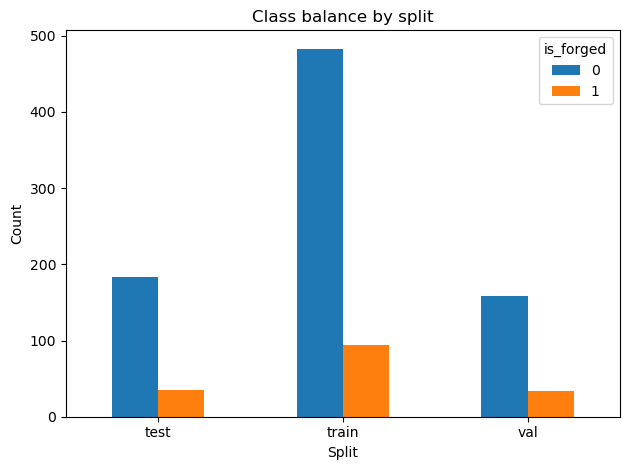

In [9]:
plt.figure(figsize=(6, 4))
(
    df.groupby(["split", "is_forged"])
      .size()
      .unstack(fill_value=0)
      .plot(kind="bar")
)
plt.title("Class balance by split")
plt.xlabel("Split")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

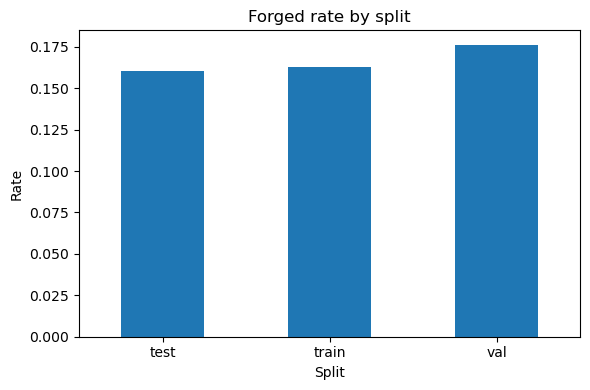

In [10]:
plt.figure(figsize=(6, 4))
split_summary.set_index("split")["forged_rate"].plot(kind="bar")
plt.title("Forged rate by split")
plt.xlabel("Split")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

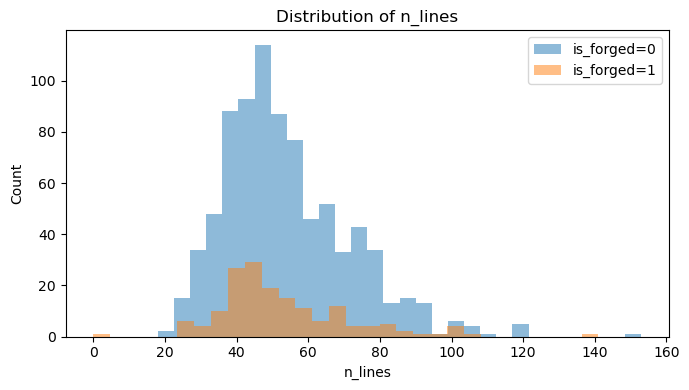

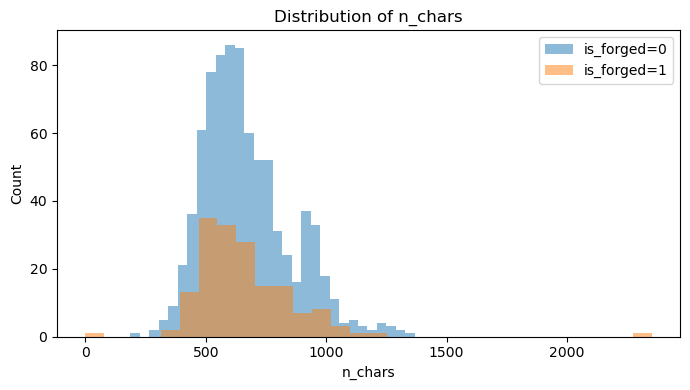

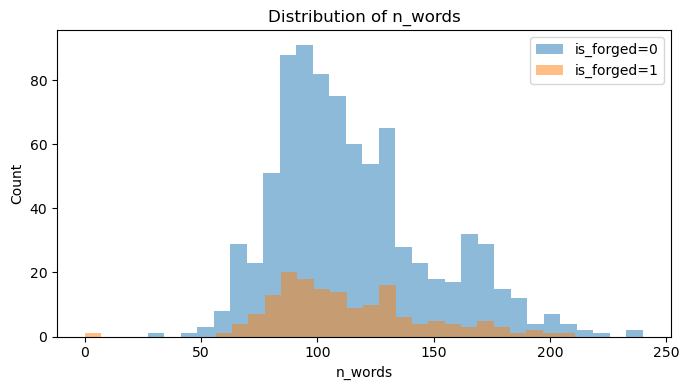

In [11]:
for col in ["n_lines", "n_chars", "n_words"]:
    plt.figure(figsize=(7, 4))
    for label, grp in df.groupby("is_forged"):
        grp[col].dropna().plot(kind="hist", bins=30, alpha=0.5, label=f"is_forged={label}")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [12]:
class_summary = (
    df.groupby("is_forged")[["n_lines", "n_chars", "n_words", "avg_line_len"]]
      .agg(["mean", "median", "std", "min", "max"])
)

class_summary

n_lines                                n_chars                                   n_words                            avg_line_len                                          
                mean median        std min  max        mean median         std  min   max        mean median        std min  max         mean     median       std       min        max
is_forged                                                                                                                                                                              
0          53.786667   50.0  17.572266  18  153  669.576970  632.0  182.893157  187  1368  115.298182  109.0  33.432453  27  240    12.825669  12.675325  2.258947  7.590361  20.772727
1          52.809816   48.0  18.565384   0  141  662.496933  615.0  217.442865    0  2351  112.914110  107.0  32.034780   0  211    12.949185  12.596154  3.506846  0.000000  42.745455

In [13]:
df["is_empty_text"] = df["n_chars"] == 0
df["very_short_text"] = df["n_words"] <= 3

print("Empty text rows:", df["is_empty_text"].sum())
print("Very short text rows:", df["very_short_text"].sum())

df.loc[df["is_empty_text"] | df["very_short_text"], ["id", "split", "is_forged", "n_lines", "n_words", "text"]].head(20)

Empty text rows: 1
Very short text rows: 1


,id,split,is_forged,n_lines,n_words,text
693,X51006619709,val,1,0,0,


In [14]:
def tokenize(text):
    text = str(text).lower()
    tokens = text.split()
    cleaned = []
    for t in tokens:
        t = "".join(ch for ch in t if ch.isalnum() or ch in [".", "/", "-", ":"])
        if t:
            cleaned.append(t)
    return cleaned

In [15]:
genuine_tokens = Counter()
forged_tokens = Counter()

for _, row in df.iterrows():
    toks = tokenize(row["text"])
    if row["is_forged"] == 1:
        forged_tokens.update(toks)
    else:
        genuine_tokens.update(toks)

top_genuine = pd.DataFrame(genuine_tokens.most_common(30), columns=["token", "count"])
top_forged = pd.DataFrame(forged_tokens.most_common(30), columns=["token", "count"])

print("Top genuine tokens")
display(top_genuine)

print("Top forged tokens")
display(top_forged)

Top genuine tokens


,token,count
0,:,3248
1,gst,2592
2,total,2271
3,1,1534
4,tax,1306
5,sr,1238
6,rm,1109
7,0.00,1076
8,6,1062
9,0,925


Top forged tokens


,token,count
0,:,534
1,gst,482
2,total,412
3,1,296
4,sr,263
5,tax,258
6,rm,229
7,0.00,206
8,6,203
9,0,195


In [16]:
all_tokens = sorted(set(genuine_tokens) | set(forged_tokens))

rows = []
for tok in all_tokens:
    g = genuine_tokens.get(tok, 0)
    f = forged_tokens.get(tok, 0)
    if g + f >= 5:  # ignore extremely rare tokens
        rows.append({
            "token": tok,
            "genuine_count": g,
            "forged_count": f,
            "forged_minus_genuine": f - g
        })

token_compare = pd.DataFrame(rows).sort_values("forged_minus_genuine", ascending=False)
token_compare.head(30)

,token,genuine_count,forged_count,forged_minus_genuine
1917,sr-,0,20,20
825,88.91,0,6,6
271,119.60,0,6,6
1089,com.,0,6,6
318,148.00,0,5,5
267,113.00,0,5,5
356,173.30,0,5,5
549,31.70,1,6,5
268,113.50,0,5,5
1494,mcd,1,5,4


In [17]:
sample_genuine = df[df["is_forged"] == 0].sample(min(3, (df["is_forged"] == 0).sum()), random_state=42)

for _, row in sample_genuine.iterrows():
    print("=" * 100)
    print("ID:", row["id"])
    print("Split:", row["split"])
    print("Forged:", row["is_forged"])
    print("Lines:", row["n_lines"], "| Words:", row["n_words"])
    print("-" * 100)
    print("\n".join(row["lines"][:20]))
    print()

ID: X51007846283
Split: val
Forged: 0
Lines: 112 | Words: 205
----------------------------------------------------------------------------------------------------
AEON CO. (M) BHD
(126926-H)
3RD FLR, AEON TAMAN MALURI SC
JLN JEJAKA, TAMAN MALURI
CHERAS, 55100 KUALA LUMPUR
GST ID : 002017394688
SHOPPING HOURS
SUN-THU:1000 HRS - 2230 HRS
FRI-SAT:1000 HRS - 2300 HRS
1X
1X
1X
1X
1X
1X
1X
1X
1X
1X
1X

ID: X51005806718
Split: train
Forged: 0
Lines: 57 | Words: 111
----------------------------------------------------------------------------------------------------
HUGO TRADING SDN BHD
BR NO.
1160956-H
LOT 8&9, KOMPLEKS PASAR BORONG
SELANGOR,
43300 SERI KEMBANGAN, SEL
03-89442249,
GST NO. : 001552822272
TAX INVOICE
13/01/2018 11:44:30PM
TRN: C2050063
COUNTER 2
QTY
UOM
CASHIER
2
UNIT AMT
PRICE
EXC.
AMT

ID: X51005587261
Split: train
Forged: 0
Lines: 51 | Words: 114
----------------------------------------------------------------------------------------------------
CHOP YEW LIAN
COMPANY NO: 0002

In [18]:
sample_forged = df[df["is_forged"] == 1].sample(min(3, (df["is_forged"] == 1).sum()), random_state=42)

for _, row in sample_forged.iterrows():
    print("=" * 100)
    print("ID:", row["id"])
    print("Split:", row["split"])
    print("Forged:", row["is_forged"])
    print("Lines:", row["n_lines"], "| Words:", row["n_words"])
    print("-" * 100)
    print("\n".join(row["lines"][:20]))
    print()

ID: X51005676541
Split: test
Forged: 1
Lines: 76 | Words: 132
----------------------------------------------------------------------------------------------------
SYARIKAT PERNIAGAAN GIN KEE
(81109-A)
NO 290, JALAN AIR PANAS,
SETAPAK,
53200, KUALA LUMPUR
TEL : 03-40210276
GST ID : 000750673920
SIMPLIFIED TAX INVOICE
CASH
DOC NO.
GOODS SOLD ARE NOT RETURNABLE, THANK YOU.
: CS00012514
DATE: 03/01/2014
CASHIER
5.37
: USER
TIME: 10:37:00
SALESPERSON :
REF. :
ITEM

ID: X51006619709
Split: val
Forged: 1
Lines: 0 | Words: 0
----------------------------------------------------------------------------------------------------


ID: X51005447851
Split: test
Forged: 1
Lines: 43 | Words: 94
----------------------------------------------------------------------------------------------------
PASARAYA BORONG PINTAR
SDN BHD
BR NO.: (124525-H)
NO 19-G& 19-1& 19-2 JALAN TASIK UTAMA 4,
MEDAN NIAGA TASIK DAMAI
016-5498845,
GST NO.:
30/01/2018 14:48:23
TAX INVOICE
TRN: CR0002815
COUNTER 3
CASHIER: 11
QTY UO

<Figure size 600x400 with 0 Axes>

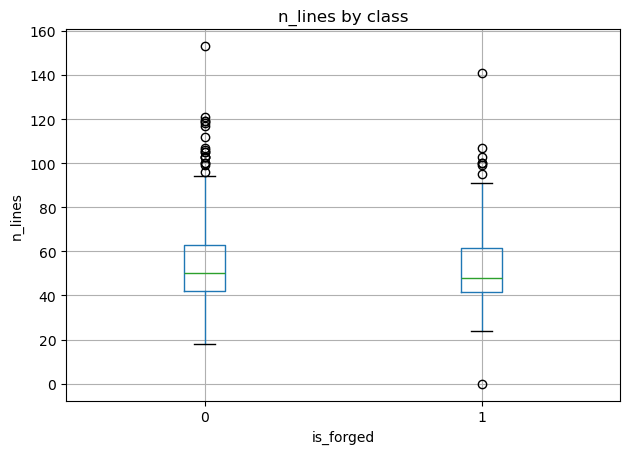

<Figure size 600x400 with 0 Axes>

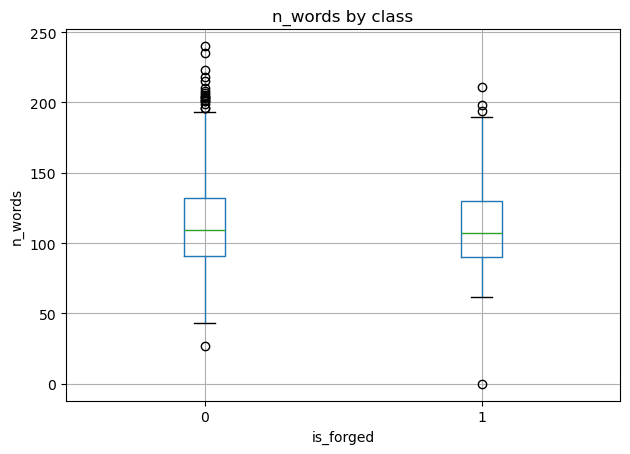

<Figure size 600x400 with 0 Axes>

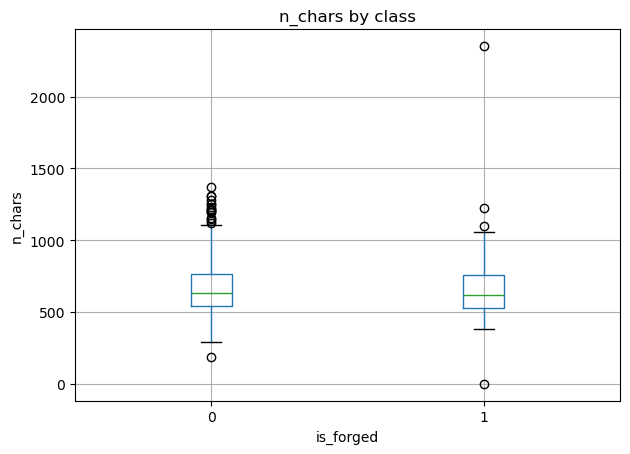

In [19]:
for col in ["n_lines", "n_words", "n_chars"]:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col, by="is_forged")
    plt.title(f"{col} by class")
    plt.suptitle("")
    plt.xlabel("is_forged")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Key Findings

- The train, validation, and test splits are loaded successfully.
- Class balance appears reasonably stable across splits.
- OCR text length features such as number of lines, words, and characters may help anomaly detection.
- Some documents may have missing images or unusually short OCR text, which should be handled in the baseline.
- Token frequency differences suggest that simple text-derived features may already provide a useful baseline for forged-document classification.

## Implications for the next step

The anomaly baseline should start with:
- text length features
- missingness / emptiness indicators
- simple lexical indicators
- a lightweight classical model such as Logistic Regression or Random Forest